<hr/>
<b>Nombre</b>: Mateo Bustamante Moreno
<br/>
<b>Cédula</b>: 1001228880


## Enunciado

**Objetivo**: El objetivo de este proyecto es utilizar la solución analítica del problema de los dos cuerpos para estudiar la aproximación del asteroide peligroso **99942 Apophis (2004 MN4)** durante el 13 de abril del año 2029.

**Procedimiento**:

1. Obtenga el vector de estado del asteroide Apophis el día de su cumpleaños en 2023 a las 00:00:00 UTC con respecto al Sol, así como el vector de estado de la Tierra respecto al mismo sistema de referencia.

2. Determine los elementos orbitales del asteroide y los elementos órbitales osculatrices de la Tierra usando el procedimiento aprendido en clase. Estos elementos orbitales serán los que usará a partir de ahora en todos los cálculos que use la teoría del problema de los dos cuerpos. Es importante que use el procedimiento en clase en lugar de obtener simplemente los elementos de astroquery.

3. Usando los elementos orbitales de ambos cuerpos determine la mínima distancia a la que se encontarán ambas órbitas en cualquier momento del futuro. A esta distancia se la llama MOID, por el acrónimo en inglés *Minimum orbital intersection distance*.

4. Para saber cuándo se producirá la máxima aproximación entre los dos cuerpos es necesario sin embargo resolver el problema de los dos cuerpos en el tiempo. Para ello use la ecuación de Kepler y los métodos aprendidos en clase para propagar hacia el futuro la posición de la Tierra y del asteroide en el tiempo y determinar la fecha, hora y distancia de la próxima aproximación. Para ello avance primero de mes en mes por ejemplo, y luego, cerca a la aproximación máxima, de día en día, de hora en hora, hasta encontrar el punto de mínima distancia. ¿En qué fecha, hora y distancia predice usted que se producirá la máxima aproximación?

5. Una vez encontrada la fecha y hora de la aproximación obtenida con el problema exclusivamente con la solución analítica del problema de los dos cuerpos (la que estamos viendo aquí), compárela con la que se obtiene recuperando de astroquery las posiciones de la Tierra y Apophis desde su cumpleaños hacia el futuro. Es decir, repita el procedimiento anterior, pero en lugar de obtener las posiciones a partir de la teoría del problema de los dos cuerpos, recupere las posiciones usando astroquery.  ¿Qué tan diferentes son los resultados de este procedimiento y del anterior? ¿podría explicar las discrepancias?

#Solución

 Importaremos los diferentes paquetes y librerias necesarías

In [ ]:
!pip install -q pymcel

In [ ]:
import numpy as np
import pymcel as pc
import spiceypy as spy

import matplotlib.pyplot as plt


from astropy.time import Time
from astropy import constants as c
from mpl_toolkits.mplot3d import Axes3D
from astroquery.jplhorizons import Horizons



Constantes útiles


In [ ]:
deg = np.pi/180
rad = 1/deg

day = 86400 # segundos
au = c.au.value # metros
G = c.G.value # m^3/(kg s^2)

Unidades canónicas

In [ ]:
UL = 1*au # m
UM = c.M_sun.value # kg
UT = (UL**3/(G*UM))**0.5 # segundos

# Unidades derivadas
UV = UL/UT

# Entonces el mu en unidades canónicas es
mu = 1


Encontramos la fecha de mi cumpleaños en días julianos


In [ ]:
jd = Time('2023-10-22 00:00:00').jd

# Punto 1)

Obtenemos el vector de estado de apophis en el día de mi cumpleaños



In [ ]:
query_ap = Horizons(id='2004 MN4', location='@10', epochs=jd)
state_ap = query_ap.vectors().to_pandas()
state_ap

,targetname,datetime_jd,datetime_str,H,G,x,y,z,vx,vy,vz,lighttime,range,range_rate
0,99942 Apophis (2004 MN4),2460239.5,A.D. 2023-Oct-22 00:00:00.0000,19.09,0.24,-0.994044,0.465334,-0.048363,-0.006039,-0.013461,0.000575,0.006345,1.098634,-0.000262


Obtenemos el vector de estado de la tierra en el día de mi cumpleaños

In [ ]:
query_e = Horizons(id='399', location='@10', epochs=jd)
state_e = query_e.vectors().to_pandas()
state_e

,targetname,datetime_jd,datetime_str,x,y,z,vx,vy,vz,lighttime,range,range_rate
0,Earth (399),2460239.5,A.D. 2023-Oct-22 00:00:00.0000,0.878899,0.467356,-0.000029,-0.008364,0.015122,-8.216211e-07,0.005749,0.995433,-0.000285


# Punto 2)

- ### Elementos orbitales de apophis

Hallemos los vectores $\vec{r}$ y $\dot{\vec{r}}$, con sus respectivas magnitudes

In [ ]:
rvec_ap = np.array(state_ap[['x','y','z']]*au/UL)[0]
r_ap = np.linalg.norm(rvec_ap)

vvec_ap = np.array(state_ap[['vx','vy','vz']]*(au/day)/UV)[0]
v_ap = np.linalg.norm(vvec_ap)

Hallemos los vectores $\vec{h}$ , $\vec{e}$ , $\vec{n}$, con sus respectivas magnitudes

In [ ]:
hvec_ap = np.cross(rvec_ap, vvec_ap)
h_ap = np.linalg.norm(hvec_ap)

evec_ap = np.cross(vvec_ap,hvec_ap)/mu - rvec_ap/r_ap
e_ap = np.linalg.norm(evec_ap)

nvec_ap = np.cross([0,0,1],hvec_ap)
n_ap = np.linalg.norm(nvec_ap)


Ahora, hallemos los elementos orbitales

In [ ]:
#Inclinación orbital
I_ap = np.arccos((hvec_ap@[0,0,1])/h_ap)


#Longitud del nodo ascendente
Omegap_ap = np.arccos((nvec_ap@[1,0,0])/n_ap)
Omega_ap = Omegap_ap if nvec_ap@[0,1,0]>=0 else 2*np.pi - Omegap_ap


#Argumento del periapsis
omegap_ap = np.arccos(evec_ap@nvec_ap/(e_ap*n_ap))
omega_ap = omegap_ap if evec_ap@[0,0,1]>=0 else 2*np.pi - omegap_ap


#Anomalía verdadera
fp_ap = np.arccos(evec_ap@rvec_ap/(e_ap*r_ap))
f_ap = fp_ap if rvec_ap@vvec_ap>=0 else 2*np.pi - fp_ap


#Semieje-mayor
p_ap = h_ap**2/mu
a_ap = p_ap/(1-e_ap**2)


#Excentricidad
e_ap = np.linalg.norm(evec_ap)

I_ap*rad,Omega_ap*rad,omega_ap*rad,f_ap*rad,e_ap,a_ap

(3.339297161979635,
 203.95660158683646,
 126.60409328815338,
 184.30579511508066,
 0.19142456410896277,
 0.9227344280914569)

- ### Elementos orbitales de la tierra

Hallemos los vectores $\vec{r}$ y $\dot{\vec{r}}$, con sus respectivas magnitudes

In [ ]:
rvec_e = np.array(state_e[['x','y','z']]*au/UL)[0]
r_e = np.linalg.norm(rvec_e)

vvec_e = np.array(state_e[['vx','vy','vz']]*(au/day)/UV)[0]
v_e = np.linalg.norm(vvec_e)

Hallemos los vectores $\vec{h}$ , $\vec{e}$ , $\vec{n}$, con sus respectivas magnitudes

In [ ]:
hvec_e = np.cross(rvec_e, vvec_e)
h_e = np.linalg.norm(hvec_e)

evec_e = np.cross(vvec_e,hvec_e)/mu - rvec_e/r_e
e_e = np.linalg.norm(evec_e)

nvec_e = np.cross([0,0,1],hvec_e)
n_e = np.linalg.norm(nvec_e)

Ahora, hallemos los elementos orbitales

In [ ]:
#Inclinación orbital
I_e = np.arccos((hvec_e@[0,0,1])/h_e)


#Longitud del nodo ascendente
Omegap_e = np.arccos((nvec_e@[1,0,0])/n_e)
Omega_e = Omegap_e if nvec_e@[0,1,0]>=0 else 2*np.pi - Omegap_e


#Argumento del periapsis
omegap_e = np.arccos(evec_e@nvec_e/(e_e*n_e))
omega_e = omegap_e if evec_e@[0,0,1]>=0 else 2*np.pi - omegap_e


#Anomalía verdadera
fp_e = np.arccos(evec_e@rvec_e/(e_e*r_e))
f_e = fp_e if rvec_e@vvec_e>=0 else 2*np.pi - fp_e


#Semieje-mayor
p_e = h_e**2/mu
a_e = p_e/(1-e_e**2)


#Excentricidad
e_e = np.linalg.norm(evec_e)


I_e*rad,Omega_e*rad,omega_e*rad,f_e*rad,e_e,a_e

(0.0032142235208391244,
 176.8874388203855,
 286.4225480436227,
 284.69190747804237,
 0.017107071442946497,
 1.000044287204446)

### Punto 3

Hallamos las matrices de rotación para apophis y la tierra

In [ ]:
# Para apophis
M_rot_ap = spy.eul2m(omega_ap,I_ap,Omega_ap,3,1,3)

# Para la tierra
M_rot_e = spy.eul2m(omega_e,I_e,Omega_e,3,1,3)


Hallaremos las órbitas de cada uno de los cuerpos, para esto variaremos la anomalía verdadera hasta que cada cuerpo complete un ciclo, y luego nos instalaremos en el sistema del observador

In [ ]:

Nf = 1000
rs_ap = np.zeros((Nf,3))
rs_e = np.zeros((Nf,3))

for i,f in enumerate(np.linspace(0,360*deg,Nf)):

  # En el sistema natural

  ##Para apophis
  r_ap = p_ap/(1 + e_ap*np.cos(f))
  xppp_ap = r_ap*np.cos(f)
  yppp_ap = r_ap*np.sin(f)
  zppp_ap = 0

  ##Para la tierra
  r_e = p_ap/(1 + e_e*np.cos(f))
  xppp_e = r_ap*np.cos(f)
  yppp_e = r_ap*np.sin(f)
  zppp_e = 0



  # En el sistema del observador

  ##Para apophis
  rs_ap[i] = spy.mxv(spy.invert(M_rot_ap),[xppp_ap,yppp_ap,zppp_ap])

  ##Para la tierra
  rs_e[i] = spy.mxv(spy.invert(M_rot_e),[xppp_e,yppp_e,zppp_e])


Gráfico de las órbitas

(-1.2112920331059984,
 1.0864334079586218,
 -1.1981646093420597,
 1.0995608317225605)

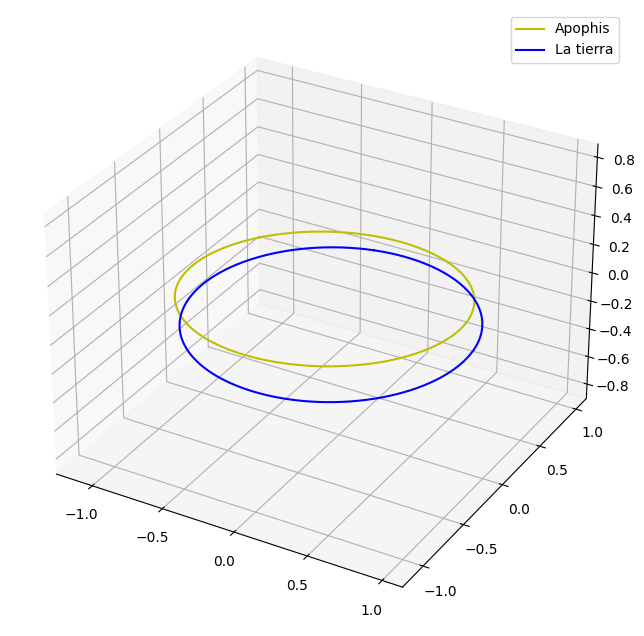

In [ ]:

plt.figure(figsize=(8,8))
ax = plt.axes(projection="3d")

fg = ax.plot(rs_ap[:,0],rs_ap[:,1],rs_ap[:,2], c="y",label="Apophis")
fg = ax.plot(rs_e[:,0],rs_e[:,1],rs_e[:,2], c="b",label="La tierra")


plt.legend()
plt.axis("equal")

Para hallar el MOID utilizaremos la siguiente idea, tomaremos una posicion fija de la órbita de apophis, y hallaremos la distancia de este punto a cada uno de los puntos de la órbita de la tierra, y luego de estas distancias escogeremos la mínima.


In [ ]:
distancias = []

for i in range(0,Nf):

  d = np.min(np.linalg.norm(abs(rs_ap[i]-rs_e),axis=1))

  distancias.append(d)


Ya que tenemos las distancias mínimas entre cada punto de las órbitas, escogeremos la menor de estas.

In [ ]:
np.min(np.array(distancias))

0.010794807264318843

**Por lo que el MOID entre apohis y la tierra es de 0.0108 **UA****

#Punto 4)

- ### Cálculos de la posición en el tiempo para apophis

Lo primero que se debe realizar es calcular la anomalía media inicial $M_{0}$,  y la velocidad angular media $n$, esta última la llamaremos en el código $nn$ para no confundir con la magnitud del vector nodal

In [ ]:
#Calculamos el E incial para poder hallar M0
E0_ap = 2*np.arctan(((1-e_ap)/(1+e_ap))**0.5*np.tan(f_ap/2))

#M0 para apophis
M0_ap = E0_ap - e_ap*np.sin(E0_ap)


#Cálculo de la velocidad angular media
nn_ap = (mu/a_ap**3)**0.5

Rutina para calcular la posición de apophis en el tiempo

In [ ]:

def posiciones_apophis(jdi):
  #M final
  Mf_ap = M0_ap + nn_ap*(jdi -jd)*day/UT


  #Anomalía excéntrica (E) final
  Ef_ap = pc.kepler_newton(Mf_ap,e_ap,delta=1e-14)[0]


  #Anomalía verdadera (f) final
  ff_ap = 2*np.arctan(np.sqrt((1+e_ap)/(1-e_ap))*np.tan(Ef_ap/2))


  #vector de estado en el sistema natural de la cónica
  r_ap = a_ap*(1-e_ap*np.cos(Ef_ap))

  xppp_ap = r_ap*np.cos(ff_ap)
  yppp_ap = r_ap*np.sin(ff_ap)
  zppp_ap = 0

  vxppp_ap = -mu/h_ap*np.sin(ff_ap)
  vyppp_ap = mu/h_ap*(e_ap+np.cos(ff_ap))
  vzppp_ap = 0


  #Vector de estado en el sistema eclíptico
  Minv_ap = spy.eul2m(-Omega_ap,-I_ap,-omega_ap,3,1,3)

  rvecf_ap = spy.mxv(Minv_ap,[xppp_ap,yppp_ap,zppp_ap])
  vvecf_ap = spy.mxv(Minv_ap,[vxppp_ap,vyppp_ap,vzppp_ap])


  #Devolvemos las posiciones de apophis en el tiempo final dado
  return rvecf_ap

- ### Calculos de la posición en el tiempo para la tierra

Se seguirá un proceso similar al anterior, pero ahora para la tierra

In [ ]:
#Calculamos el E incial para poder hallar M0
E0_e = 2*np.arctan(((1-e_e)/(1+e_e))**0.5*np.tan(f_e/2))

#M0 para la tierra
M0_e = E0_e - e_e*np.sin(E0_e)


#Cálculo de la velocidad angular media
nn_e = (mu/a_e**3)**0.5

Rutina para calcular la posición de la tierra en el tiempo

In [ ]:

def posiciones_earth(jdi):
  #M final
  Mf_e = M0_e + nn_e*(jdi-jd)*day/UT


  #E final
  Ef_e = pc.kepler_newton(Mf_e,e_e,delta=1e-14)[0]


  #f final
  ff_e = 2*np.arctan(np.sqrt((1+e_e)/(1-e_e))*np.tan(Ef_e/2))


  #vector de estado en el sistema natural de la cónica
  r_e = a_e*(1-e_e*np.cos(Ef_e))

  xppp_e = r_e*np.cos(ff_e)
  yppp_e = r_e*np.sin(ff_e)
  zppp_e = 0

  vxppp_e = -mu/h_e*np.sin(ff_e)
  vyppp_e = mu/h_e*(e_e+np.cos(ff_e))
  vzppp_e = 0


  #Vector de estado en el sistema eclíptico
  Minv_e = spy.eul2m(-Omega_e,-I_e,-omega_e,3,1,3)

  rvecf_e = spy.mxv(Minv_e,[xppp_e,yppp_e,zppp_e])
  vvecf_e = spy.mxv(Minv_e,[vxppp_e,vyppp_e,vzppp_e])


  #Devolvemos las posiciones de la tierra en el tiempo final dado
  return rvecf_e


- ### Calculos de la fecha y la distancia de la máxima aproximación

- #### Calcularemos las diferentes posiciones de apophis y la tierra en un lapso de 9 años, primeramente iremos variando mes a mes para ver donde hay una mayor aproximación de los cuerpos

In [ ]:
año = 365.25 #días
mes = año/12

posiciones_ap = []
posiciones_e = []

#tiempo final 9 años
jdff = jd + año*9

#Variación, mes a mes
jdi = jd + año/12

while jdi<=jdff:

  posiciones_ap.append(posiciones_apophis(jdi))
  posiciones_e.append(posiciones_earth(jdi))

  #vamos sumando mes a mes
  jdi += mes

Debido a que tenemos dos listas, una con las posiciones de apophis y otra con las posiciones de la tierra a lo largo del tiempo, hallaremos la aproximación que hay entre cada par de datos.

In [ ]:
#nueva lista con las aproximaciones, mes a mes
Aproximaciones_m_m = np.linalg.norm(abs(np.array(posiciones_ap)-np.array(posiciones_e)),axis=1)

Ahora que tenemos las aproximaciones, queremos ver donde ocurre la máxima, para ello encontraremos el índice de la lista donde esto pasa

In [ ]:
np.argmin(Aproximaciones_m_m)

65

Encontramos que el índice es 65, como estabamos variando mes a mes, esto quiere decir que la máxima aproximación ocurrirá 65 meses después del tiempo incial que fue el "$2023-10-22 \ \ \ \  00:00:00$"

Para tener algo más preciso, acortaremos el rango de tiempos, es claro que la aproximación más cercana ocurrirá entonces entre 64 y 66 meses después de la fecha inicial.

In [ ]:

jd1 = jd + mes*64
jd2 = jd + mes*66


# Convertimos de dia juliano a un objeto de Time
t1 = Time(jd1, format='jd')
t2 = Time(jd2, format='jd')

# Convertimos el objeto time a una fecha UTC
utc1 = t1.to_datetime()
utc2 = t2.to_datetime()


print(utc1)
print(utc2)

2029-02-20 00:00:00
2029-04-21 21:00:00


/usr/local/lib/python3.10/dist-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


Por lo que la máxima aproximación ocurrirá entre "$2029-02-20 \ \ \ \ \ 00:00:00$"   y     "$2029-04-21 \ \ \ \ \ 21:00:00$"

- #### Haremos el mismo proceso que antes, pero ahora este nuevo rango lo variaremos día a día

In [ ]:
#se tomó que un mes es de 30 días
dia = mes/30


posiciones_ap_d_d = []
posiciones_e_d_d = []

#jd1 es el tiempo incial y el final jd2
jdi = jd1

while jdi<=jd2:

  posiciones_ap_d_d.append(posiciones_apophis(jdi))
  posiciones_e_d_d.append(posiciones_earth(jdi))

  #vamos sumando días
  jdi += dia

Hallaremos las aproximaciones en este nuevo rango, día a día

In [ ]:
Aproximaciones_d_d = np.linalg.norm(abs(np.array(posiciones_ap_d_d)-np.array(posiciones_e_d_d)),axis=1)

Ahora que tenemos las aproximaciones, queremos ver donde ocurre la máxima, para ello encontraremos el índice de la lista donde esto pasa

In [ ]:
np.argmin(Aproximaciones_d_d)

52

Encontramos que el índice es 52, como estabamos variando día a día, esto quiere decir que la máxima aproximación ocurrirá 52 días después del nuevo tiempo incial que es "$2029-02-20 \ \ \ \ \ 00:00:00$"

Para tener algo más preciso, acortaremos el rango de tiempos, es claro que la aproximación más cercana ocurrirá entre 51 y 53 días después de la fecha anterior

In [ ]:
jdd1=jd1 + dia*51
jdd2=jd1 + dia*53


# Convertimos de dia juliano a un objeto de Time
td1 = Time(jdd1, format='jd')
td2 = Time(jdd2, format='jd')

# Convertimos el objeto time a una fecha UTC
utcd1 = td1.to_datetime()
utcd2 = td2.to_datetime()


print(utcd1)
print(utcd2)

2029-04-12 17:50:59.999992
2029-04-14 18:33:00.000003


Por lo que la máxima aproximación ocurrirá entre "$2029-04-12 \ \ \ \ \ 17:51:00$"   y     "$2029-04-14 \ \ \ \ \ 18:33:00$"

- #### Haremos el mismo proceso que antes, pero ahora este nuevo rango lo variaremos hora a hora

In [ ]:
hora = dia/24

posiciones_ap_h_h = []
posiciones_e_h_h = []

jdi = jdd1
while jdi<=jdd2:

  posiciones_ap_h_h.append(posiciones_apophis(jdi))
  posiciones_e_h_h.append(posiciones_earth(jdi))

  #iremos sumando horas
  jdi += hora

Hallaremos las aproximaciones en este nuevo rango, hora a hora

In [ ]:
Aproximaciones_h_h = np.linalg.norm(abs(np.array(posiciones_ap_h_h)-np.array(posiciones_e_h_h)),axis=1)

Ahora que tenemos las aproximaciones, queremos ver donde ocurre la máxima, para ello encontraremos el índice de la lista donde esto pasa

In [ ]:
np.argmin(Aproximaciones_h_h)

12

Encontramos que el índice es 12, como estabamos variando hora a hora, esto quiere decir que la máxima aproximación ocurrirá 12 horas después del nuevo tiempo incial que es "$2029-04-12 \ \ \ \ \ 17:51:00$"

Hallemos el día juliano para la fecha anterior más 12 horas, y lo convertiremos a una fecha

In [ ]:
jd_final = jdd1 + hora*12

# Convertimos de dia juliano a un objeto de Time
t_final = Time(jd_final, format='jd')


# Convertimos el objeto time a una fecha UTC
utc_final = t_final.to_datetime()

print(utc_final)

2029-04-13 06:01:29.999995


Además tenemos la lista de aproximaciones en este nuevo rango, se llamó "Aproximaciones_h_h" y vimos que la máxima aproximación ocurre en el índice 12, por lo que esa será la distancia a la que estarán los cuerpos.

In [ ]:
np.linalg.norm(abs(np.array(posiciones_ap_h_h)-np.array(posiciones_e_h_h))[12])

0.018084839535533463

### Se predice entonces que en un lapso de 9 años la máxima aproximación entre apophis y la tierra, calculada con el problema de los dos cuerpos, será el $2029-04-13$  a las $06:01:30$ , y se acercarán a una distancia de $0.0181$ Unidades astronómicas

# Punto 5)

- ### Calcularemos las diferentes posiciones de apophis y la tierra en un lapso de 9 años con astroquery, primeramente iremos variando mes a mes para ver donde hay una mayor aproximación de los cuerpos

- #### Rango de tiempo, desde la fecha de mi cumpleaños hasta 9 años en el futuro, varinado cada mes.

In [ ]:
jdf_astro = np.arange(jd, jd + año*9, mes)

Calculamos los diferentes datos de apophis y la tierra con astroquery

In [ ]:
#Para apophis
query_m_m_ap = Horizons(id='2004 MN4', location='@10', epochs=jdf_astro)
state_m_m_ap = query_m_m_ap.vectors().to_pandas()


#Para la tierra
query_m_m_e = Horizons(id='399', location='@10', epochs=jdf_astro)
state_m_m_e = query_m_m_e.vectors().to_pandas()

Recuperamos las posiciones de los dos cuerpos

In [ ]:
#Posiciones de apophis
pos_astro_m_m_ap = np.array(state_m_m_ap[['x','y','z']]*au/UL)

#Posiciones de la tierra
pos_astro_m_m_e = np.array(state_m_m_e[['x','y','z']]*au/UL)


hallaremos la aproximación que hay entre cada par de datos.

In [ ]:
Aprox_astro_m_m = np.linalg.norm(abs(np.array(pos_astro_m_m_ap)-np.array(pos_astro_m_m_e)),axis=1)

Ahora que tenemos las aproximaciones, queremos ver donde ocurre la máxima, para ello encontraremos el índice de la lista donde esto pasa

In [ ]:
np.argmin(Aprox_astro_m_m)

66

Encontramos que el índice es 66, como estabamos variando mes a mes, esto quiere decir que la máxima aproximación ocurrirá 66 meses después del tiempo incial que fue el "$2023-10-22 \ \ \ \  00:00:00$"

Para tener algo más preciso, acortaremos el rango de tiempos, es claro que la aproximación más cercana ocurrirá entonces entre 65 y 67 meses después de la fecha inicial.

In [ ]:

jd_astro1 = jd + mes*65
jd_astro2 = jd + mes*67


# Convertimos de dia juliano a un objeto de Time
t_astro1 = Time(jd_astro1, format='jd')
t_astro2 = Time(jd_astro2, format='jd')

# Convertimos el objeto time a una fecha UTC
utc_astro1 = t_astro1.to_datetime()
utc_astro2 = t_astro2.to_datetime()


print(utc_astro1)
print(utc_astro2)

2029-03-22 10:30:00
2029-05-22 07:30:00


/usr/local/lib/python3.10/dist-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


Por lo que la máxima aproximación ocurrirá entre "$2029-03-22 \ \ \ \ \ 10:30:00$"   y     "$2029-05-22 \ \ \ \ \ 07:30:00$"

- #### Haremos el mismo proceso que antes, pero ahora este nuevo rango lo variaremos día a día

Las dos fechas anteriores serán el nuevo rango de tiempos

In [ ]:
new_jdi_astro_d = state_m_m_e['datetime_jd'][65]

new_jdf_astro_d = state_m_m_e['datetime_jd'][67]

jdf_astro_d = np.arange(new_jdi_astro_d, new_jdf_astro_d,dia)

Calculamos los datos de apophis y la tierra con astroquery en este nuevo rango de tiempos.

In [ ]:
query_d_d_ap = Horizons(id='2004 MN4', location='@10', epochs=jdf_astro_d)
state_d_d_ap = query_d_d_ap.vectors().to_pandas()


query_d_d_e = Horizons(id='399', location='@10', epochs=jdf_astro_d)
state_d_d_e = query_d_d_e.vectors().to_pandas()

Recuperamos las posiciones de los dos cuerpos

In [ ]:
pos_astro_d_d_ap = np.array(state_d_d_ap[['x','y','z']]*au/UL)

pos_astro_d_d_e = np.array(state_d_d_e[['x','y','z']]*au/UL)


Hallaremos las aproximaciones en este nuevo rango, día a día

In [ ]:
Aprox_astro_d_d = np.linalg.norm(abs(np.array(pos_astro_d_d_ap )-np.array(pos_astro_d_d_e)),axis=1)

Ahora que tenemos las aproximaciones, queremos ver donde ocurre la máxima, para ello encontraremos el índice de la lista donde esto pasa

In [ ]:
np.argmin(Aprox_astro_d_d)

22

Encontramos que el índice es 22, como estabamos variando día a día, esto quiere decir que la máxima aproximación ocurrirá 22 días después del nuevo tiempo incial que es "$2029-03-22 \ \ \ \ \ 10:30:00$"

Para tener algo más preciso, acortaremos el rango de tiempos, es claro que la aproximación más cercana ocurrirá entonces entre 21 y 23 días después de la fecha anterior.

In [ ]:

jd_astro3 = new_jdi_astro_d + dia*21
jd_astro4 = new_jdi_astro_d + dia*23


# Convertimos de dia juliano a un objeto de Time
t_astro3 = Time(jd_astro3, format='jd')
t_astro4 = Time(jd_astro4, format='jd')

# Convertimos el objeto time a una fecha UTC
utc_astro3 = t_astro3.to_datetime()
utc_astro4 = t_astro4.to_datetime()


print(utc_astro3)
print(utc_astro4)

2029-04-12 17:50:59.999992
2029-04-14 18:33:00.000003


/usr/local/lib/python3.10/dist-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


Por lo que la máxima aproximación ocurrirá entre "$2029-04-12 \ \ \ \ \ 17:51:00$"   y     "$2029-04-14 \ \ \ \ \ 18:33:00$"

- #### Haremos el mismo proceso que antes, pero ahora este nuevo rango lo variaremos hora a hora

Las dos fechas anteriores serán el nuevo rango de tiempos

In [ ]:
new_jdi_astro_h = state_d_d_e['datetime_jd'][21]

new_jdf_astro_h = state_d_d_e['datetime_jd'][23]

jdf_astro_h = np.arange(new_jdi_astro_h, new_jdf_astro_h,hora)

Calculamos los datos de apophis y la tierra con astroquery en este nuevo rango de tiempos.

In [ ]:
query_h_h_ap = Horizons(id='2004 MN4', location='@10', epochs=jdf_astro_h)
state_h_h_ap = query_h_h_ap.vectors().to_pandas()

query_h_h_e = Horizons(id='399', location='@10', epochs=jdf_astro_h)
state_h_h_e = query_h_h_e.vectors().to_pandas()

Recuperamos las posiciones de los dos cuerpos

In [ ]:
pos_astro_h_h_ap = np.array(state_h_h_ap[['x','y','z']]*au/UL)

pos_astro_h_h_e = np.array(state_h_h_e[['x','y','z']]*au/UL)


Hallaremos las aproximaciones en este nuevo rango, hora a hora

In [ ]:
Aprox_astro_h_h = np.linalg.norm(abs(np.array(pos_astro_h_h_ap )-np.array(pos_astro_h_h_e)),axis=1)

Ahora que tenemos las aproximaciones, queremos ver donde ocurre la máxima, para ello encontraremos el índice de la lista donde esto pasa

In [ ]:
np.argmin(Aprox_astro_h_h)

28

Encontramos que el índice es 28, como estabamos variando día a día, esto quiere decir que la máxima aproximación ocurrirá 28 horas después del nuevo tiempo incial que es "$2029-04-12 \ \ \ \ \ 17:51:00$"

Hallemos el día juliano para la fecha anterior más 28 horas, y lo convertiremos a una fecha


In [ ]:
jd_astro_final = new_jdi_astro_h + hora*28

# Convertimos de dia juliano a un objeto de Time
t_astro_final = Time(jd_astro_final, format='jd')


# Convertimos el objeto time a una fecha UTC
utc_astro_final = t_astro_final.to_datetime()

print(utc_astro_final)

2029-04-13 22:15:30.000092


/usr/local/lib/python3.10/dist-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


Además tenemos la lista de aproximaciones en este nuevo rango, que se llamó "Aprox_astro_h_h" y vimos que la máxima aproximación ocurre en el índice 28, por lo que esa será la distancia a la que estarán los cuerpos.

In [ ]:
Aprox_astro_h_h[28]

0.0002659055798174365

### Se predice entonces que en un lapso de 9 años la máxima aproximación entre apophis y la tierra, calculada con astroquery, será el $2029-04-13$  a las $22:15:30$ , y se acercarán a una distancia de $0.000266$ Unidades astronómicas

- ### Gráfico de la distancia entre Apophis y la Tierra como función del tiempo desde la fecha de nacimiento hasta la máxima aproximación, calculada con la teoría del problema de los dos cuerpos y con los datos de Astroquery.

Al incio cuando calculamos los datos de astroquery para cada cuerpo usamos un rango de tiempos de 9 años variando cada mes, se utilizaron dias julianos, ahora los pasaremos a fechas

In [ ]:
# Convertimos el rango de dias julianos a un objeto Time
t_p = Time(jdf_astro, format='jd')


# Convertimos el objeto Time a una fecha UTC
u = t_p.to_datetime()

/usr/local/lib/python3.10/dist-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 69 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


Realizamos el gráfico

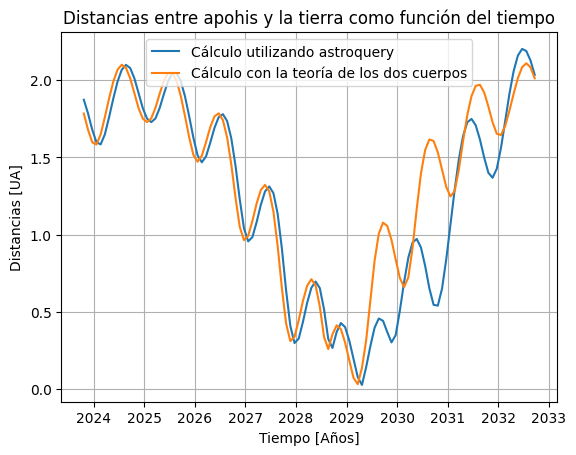

In [ ]:
plt.title("Distancias entre apohis y la tierra como función del tiempo")

plt.plot(u, Aprox_astro_m_m,label="Cálculo utilizando astroquery")
plt.plot(u, Aproximaciones_m_m,label="Cálculo con la teoría de los dos cuerpos")
plt.ylabel("Distancias [UA]")
plt.xlabel("Tiempo [Años]")
plt.grid()
plt.legend()

#### Si existe cierta diferencia entre los métodos, al hallar las fechas hay una pequeña diferencia, que se ve más notoria en las distancias. Aunque el método de los dos cuerpos tiene una gran aproximación a la realidad, existen discrepancias, sobre todo cuando se aumenta el tiempo, esto debido a que en la teoría de los dos cuerpos hay muchos más cálculos númericos, y esta falta de precisión se ve reflejada con el tiempo.